In [1]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]


    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/P_o[i]
        gamma.append(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [41]:
# define constants
k_C = Decimal(15)
n_d = Decimal(1)
n_dE = Decimal(0.99)

beta = Decimal(25)

delta_e = Decimal(100)

In [55]:
# Generating synthetic curve for comparison
D_init = Decimal(1000)
P_init = Decimal(9.e5)
E_init = Decimal(1e5)

D_e = simulate_vals(D_init=D_init,
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=44)[2]

D_e = np.array([float(str(x)) for x in D_e])


# Reading in initial curve for comparison
known_df = pd.read_csv('./data/known_dilution_multicomponent.csv')
known_df.head(2)
curve = known_df.loc[(known_df.loc[:,'Well Position'] == 'A1'), 'FAM']
curve = np.array(curve)
# curve -= curve[0] #NOTE THAT WE ARE SHIFTING THE CURVE DOWN !!! NEED TO ADDRESS LATER


def func_to_optimize(params):
    tried_params.append(params)
    
    D_e_cur = simulate_vals(D_init=Decimal(10**params[0]),
                        E_init=Decimal(10**params[1]), 
                        P_init=Decimal(10**params[2]), 
                        delta_e=Decimal(10**params[4]),
                        n_d=Decimal(10**0),
                        n_dE=Decimal(10**0),
                        k_C=Decimal(10**params[7]),
                        beta=Decimal(10**params[8]),
                        n_cycle=44)[2]
    D_e_cur = np.array([float(str(x)) + 10**params[3] for x in D_e_cur])
    return ((curve - D_e_cur)**2).mean()
        

In [56]:
from scipy.optimize import minimize

init_params = np.array([4, 6, 5, 5, 1, 0, 0, 1, 1])
tried_params = []

res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-2, 'disp': True})
print(tried_params)
print(10**res.x)

Optimization terminated successfully.
         Current function value: 116199551.901158
         Iterations: 1069
         Function evaluations: 1633
[array([4., 6., 5., 5., 1., 0., 0., 1., 1.]), array([4.2, 6. , 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4. , 6.3, 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4.  , 6.  , 5.25, 5.  , 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.25, 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.05, 0.  , 0.  , 1.  , 1.  ]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 2.5e-04, 0.0e+00,
       1.0e+00, 1.0e+00]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 0.0e+00, 2.5e-04,
       1.0e+00, 1.0e+00]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.05, 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.  , 1.05]), array([4.04444444e+00, 6.06666667e+00, 5.05555556e+00, 5.05555556e+00,
       1.01111111e+00, 5.55555556e-05, 5.55555556e-05, 9.50000000e-01,
       1.01111111e+00]), array([ 4.05432099e+

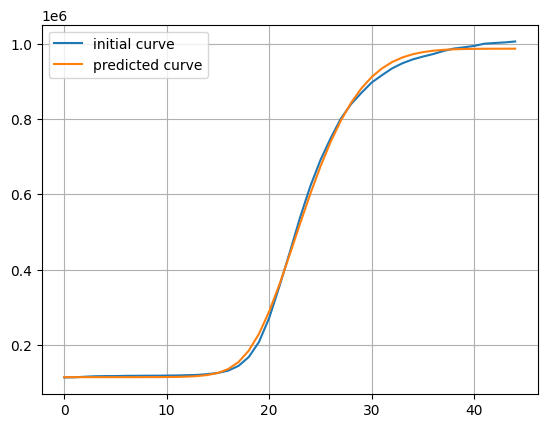

In [57]:
plt.plot(curve, label = 'initial curve')

D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=Decimal(10**res.x[4]),
                    n_d=Decimal(10**0),
                    n_dE=Decimal(10**0),
                    k_C=Decimal(10**res.x[7]),
                    beta=Decimal(10**res.x[8]),
                    n_cycle=44)[2]

D_e_pred = np.array([float(str(x)) + 10**res.x[3] for x in D_e_pred])

plt.plot(D_e_pred, label = 'predicted curve')
plt.legend()
plt.grid()